In [ ]:
import pandas as pd

In [ ]:
stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

In [ ]:
print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


In [ ]:
inventory.head()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,1,NaN,12.50,8.79,N,Safe
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,1,NaN,11.80,8.55,N,Safe


In [ ]:
inventory.columns


Index(['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock',
       'units_demanded', 'units_sold', 'closing_stock', 'reorder_point',
       'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual',
       'sales_velocity_7d', 'days_of_cover', 'is_festival_week',
       'stockout_risk'],
      dtype='object')

In [ ]:
inventory["stockout_risk"].value_counts()

,count
stockout_risk,
Safe,14131
At-Risk,5186
Imminent,2283


In [ ]:
inventory["stockout_risk"].value_counts(normalize=True) * 100

,proportion
stockout_risk,
Safe,65.421296
At-Risk,24.009259
Imminent,10.569444


In [ ]:
inventory.isnull().sum()

,0
date,0
store_id,0
sku_id,0
supplier_id,0
opening_stock,0
units_demanded,0
units_sold,0
closing_stock,0
reorder_point,0
reorder_placed,0


In [ ]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     21600 non-null  object 
 1   store_id                 21600 non-null  object 
 2   sku_id                   21600 non-null  object 
 3   supplier_id              21600 non-null  object 
 4   opening_stock            21600 non-null  float64
 5   units_demanded           21600 non-null  int64  
 6   units_sold               21600 non-null  float64
 7   closing_stock            21600 non-null  float64
 8   reorder_point            21600 non-null  float64
 9   reorder_placed           21600 non-null  object 
 10  lead_time_days_expected  21600 non-null  int64  
 11  lead_time_days_actual    1701 non-null   float64
 12  sales_velocity_7d        21600 non-null  float64
 13  days_of_cover            21600 non-null  float64
 14  is_festival_week      

In [ ]:
print("Stores:")
print(stores.shape)

print("\nSKUs:")
print(skus.shape)

print("\nSuppliers:")
print(suppliers.shape)

print("\nEvents:")
print(events.shape)

Stores:
(12, 8)

SKUs:
(60, 9)

Suppliers:
(15, 6)

Events:
(30, 5)


In [ ]:
stores.head()

,store_id,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders
0,ST01,Mumbai,Mumbai,Tier1,Large,2946,2023,580
1,ST02,Mumbai,Mumbai,Tier1,Small,1482,2024,235
2,ST03,Bengaluru,BENGALURU,Tier1,Large,3650,2022,552
3,ST04,Bengaluru,Bengaluru,Tier1,Large,4198,2025,524
4,ST05,Delhi,Delhi,Tier1,Medium,2220,2022,343


In [ ]:
skus.head()

,sku_id,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_id
0,SKU001,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11
1,SKU002,Tomato 1kg,Fruits & Vegetables,148.76,3,Y,N,Medium,SUP08
2,SKU003,Onion 1kg,Fruits & Vegetables,66.13,3,Y,N,High,SUP01
3,SKU004,Potato 1kg,Fruits & Vegetables,51.99,5,Y,N,High,SUP01
4,SKU005,Apple 1kg,Fruits & Vegetables,145.91,5,Y,N,Medium,SUP08


In [ ]:
suppliers.head()

,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days
0,SUP01,Fresh Farms Co,Fruits & Vegetables,0.92,5,0.8
1,SUP02,Green Valley Distributors,Snacks,0.93,3,0.8
2,SUP03,Metro Dairy Supplies,Snacks,0.90,2,1.7
3,SUP04,Sunrise Agro Traders,"Beverages, Dairy",0.70,1,0.7
4,SUP05,National Snacks Ltd,Home Care,0.66,2,2.2


In [ ]:
events.head()

,date,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,Regular Day,none,1.0,1.0
1,2026-10-02,Regular Day,none,1.0,1.0
2,2026-10-03,Regular Day,none,1.0,1.0
3,2026-10-04,Regular Day,none,1.0,1.0
4,2026-10-05,Regular Day,none,1.0,1.0


In [ ]:
suppliers["reliability_score"].isnull().sum()

np.int64(3)

In [ ]:
suppliers[suppliers["reliability_score"].isnull()]

,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days
5,SUP06,QuickBev Distributors,"Personal Care, Home Care",NaN,1,2.2
13,SUP14,Prime Personal Care,Staples,NaN,4,1.9
14,SUP15,Regional Produce Hub,Beverages,NaN,5,2.1


In [ ]:
reliability_median = suppliers["reliability_score"].median()

suppliers["reliability_score"] = suppliers["reliability_score"].fillna(reliability_median)

In [ ]:
suppliers["reliability_score"].isnull().sum()

np.int64(0)

In [ ]:
stores["city_display"] = stores["city_display"].str.title()

In [ ]:
stores[["city", "city_display"]]

,city,city_display
0,Mumbai,Mumbai
1,Mumbai,Mumbai
2,Bengaluru,Bengaluru
3,Bengaluru,Bengaluru
4,Delhi,Delhi
5,Delhi,Delhi
6,Pune,Pune
7,Pune,Pune
8,Hyderabad,Hyderabad
9,Hyderabad,Hyderabad


In [ ]:
data = inventory.merge(stores, on="store_id", how="left")
data.shape

(21600, 23)

In [ ]:
data = data.merge(skus, on="sku_id", how="left")
data.shape

(21600, 31)

In [ ]:
data = inventory.merge(stores, on="store_id", how="left")
data = data.merge(skus, on="sku_id", how="left", suffixes=("", "_sku"))

data.shape

(21600, 31)

In [ ]:
data.columns

Index(['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock',
       'units_demanded', 'units_sold', 'closing_stock', 'reorder_point',
       'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual',
       'sales_velocity_7d', 'days_of_cover', 'is_festival_week',
       'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size',
       'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category',
       'unit_price_inr', 'shelf_life_days', 'is_perishable',
       'festive_relevant', 'popularity_tier', 'supplier_id_sku'],
      dtype='object')

In [ ]:
data = data.merge(suppliers, on="supplier_id", how="left")
data.shape

(21600, 36)

In [ ]:
data = data.merge(events, on="date", how="left")
data.shape

(21600, 40)

In [ ]:
data.columns

Index(['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock',
       'units_demanded', 'units_sold', 'closing_stock', 'reorder_point',
       'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual',
       'sales_velocity_7d', 'days_of_cover', 'is_festival_week',
       'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size',
       'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category',
       'unit_price_inr', 'shelf_life_days', 'is_perishable',
       'festive_relevant', 'popularity_tier', 'supplier_id_sku',
       'supplier_name', 'categories_supplied', 'reliability_score',
       'base_lead_time_days', 'lead_time_variance_days', 'event_name',
       'event_type', 'demand_multiplier_festive', 'demand_multiplier_other'],
      dtype='object')

In [ ]:
data.isnull().sum()

,0
date,0
store_id,0
sku_id,0
supplier_id,0
opening_stock,0
units_demanded,0
units_sold,0
closing_stock,0
reorder_point,0
reorder_placed,0


In [ ]:
data["reorder_gap"] = data["reorder_point"] - data["closing_stock"]

In [ ]:
data[["reorder_point", "closing_stock", "reorder_gap"]].head()

,reorder_point,closing_stock,reorder_gap
0,36.4,144.9,-108.5
1,36.4,134.9,-98.5
2,36.4,119.9,-83.5
3,36.4,109.9,-73.5
4,36.4,100.9,-64.5


In [ ]:
data["days_of_cover_ratio"] = data["days_of_cover"] / data["lead_time_days_expected"]

In [ ]:
data[["days_of_cover", "lead_time_days_expected", "days_of_cover_ratio"]].head()

,days_of_cover,lead_time_days_expected,days_of_cover_ratio
0,9.66,1,9.66
1,10.79,1,10.79
2,8.99,1,8.99
3,8.79,1,8.79
4,8.55,1,8.55


In [ ]:
data["date"] = pd.to_datetime(data["date"])

In [ ]:
data["day_of_month"] = data["date"].dt.day

In [ ]:
data["festival_flag"] = data["is_festival_week"].map({"Y": 1, "N": 0})

In [ ]:
data["day_of_week"] = data["date"].dt.dayofweek
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

In [ ]:
data[["date", "day_of_month", "is_festival_week", "festival_flag", "day_of_week", "is_weekend"]].head(10)

,date,day_of_month,is_festival_week,festival_flag,day_of_week,is_weekend
0,2026-10-01,1,N,0,3,0
1,2026-10-02,2,N,0,4,0
2,2026-10-03,3,N,0,5,1
3,2026-10-04,4,N,0,6,1
4,2026-10-05,5,N,0,0,0
5,2026-10-06,6,N,0,1,0
6,2026-10-07,7,N,0,2,0
7,2026-10-08,8,N,0,3,0
8,2026-10-09,9,N,0,4,0
9,2026-10-10,10,N,0,5,1


In [ ]:
train = data[data["date"] <= "2026-10-23"].copy()
test = data[data["date"] >= "2026-10-24"].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (16560, 46)
Test: (5040, 46)


In [ ]:
data = data.sort_values(["store_id", "sku_id", "date"])

data["reorder_flag"] = (data["reorder_placed"] == "Y").astype(int)

data["is_recent_reorder"] = (
    data.groupby(["store_id", "sku_id"])["reorder_flag"]
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).max()
    )
    .fillna(0)
    .astype(int)
)

print(data["is_recent_reorder"].value_counts())

is_recent_reorder
0    16833
1     4767
Name: count, dtype: int64


In [ ]:
features = [
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "sales_velocity_7d",
    "days_of_cover",
    "reorder_gap",
    "days_of_cover_ratio",
    "reliability_score",
    "base_lead_time_days",
    "lead_time_variance_days",
    "lead_time_days_expected",
    "unit_price_inr",
    "shelf_life_days",
    "baseline_daily_orders",
    "is_recent_reorder",
    "day_of_month",
    "festival_flag",
    "is_weekend",
    "is_perishable",
    "festive_relevant",
    "category",
    "popularity_tier",
    "store_size",
    "city"
]

X = pd.get_dummies(
    data[features],
    drop_first=True
)

y = data["stockout_risk"]

X_train = X.loc[train.index]
X_test = X.loc[test.index]

y_train = train["stockout_risk"]
y_test = test["stockout_risk"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16560, 38)
X_test: (5040, 38)


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print("=== BASELINE ===")
print(classification_report(y_test, baseline_pred, zero_division=0))
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)
logreg.fit(X_train_scaled, y_train)
lr_pred = logreg.predict(X_test_scaled)
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred, zero_division=0))

=== BASELINE ===
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

     At-Risk       0.88      0.72      0.79      1126
    Imminent       0.71      0.90      0.79       775
        Safe       0.99      0.99      0.99      3139

    accuracy                           0.92      5040
   macro avg       0.86      0.87      0.86      5040
weighted avg       0.92      0.92      0.92      5040



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred, zero_division=0))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

     At-Risk       0.84      0.92      0.88      1126
    Imminent       0.87      0.75      0.80       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.94      5040
   macro avg       0.90      0.89      0.89      5040
weighted avg       0.94      0.94      0.94      5040



In [ ]:
from sklearn.metrics import accuracy_score, recall_score

results = []

models = {
    "Baseline": baseline_pred,
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():

    accuracy = accuracy_score(y_test, pred)

    imminent_recall = recall_score(
        y_test,
        pred,
        labels=["Imminent"],
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 3),
        "Imminent Recall": round(imminent_recall, 3)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Imminent Recall
0,Baseline,0.623,0.000
1,Logistic Regression,0.916,0.901
2,Random Forest,0.943,0.751


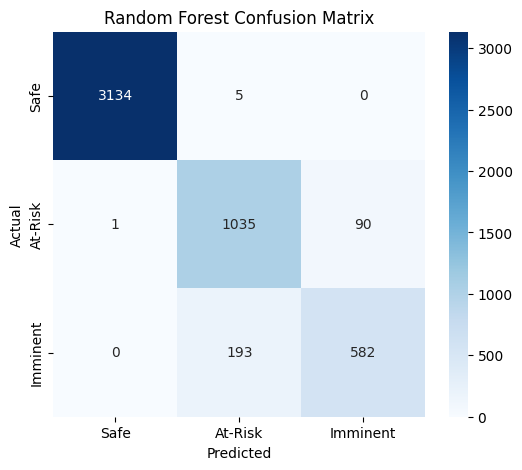

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Safe", "At-Risk", "Imminent"]

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 important features:")
print(importance.head(15))

Top 15 important features:
reorder_gap                0.223331
days_of_cover              0.220678
days_of_cover_ratio        0.208856
closing_stock              0.063509
opening_stock              0.031014
reliability_score          0.029174
sales_velocity_7d          0.024953
reorder_point              0.021190
lead_time_variance_days    0.018776
is_recent_reorder          0.018402
lead_time_days_expected    0.017903
base_lead_time_days        0.016142
units_sold                 0.014934
units_demanded             0.014819
day_of_month               0.014261
dtype: float64


In [ ]:
festival_result = pd.crosstab(
    data["is_festival_week"],
    data["stockout_risk"],
    normalize="index"
) * 100

festival_result = festival_result[["Safe", "At-Risk", "Imminent"]]

print(festival_result.round(2))

stockout_risk      Safe  At-Risk  Imminent
is_festival_week                          
N                 66.30    24.19      9.51
Y                 54.89    21.80     23.31


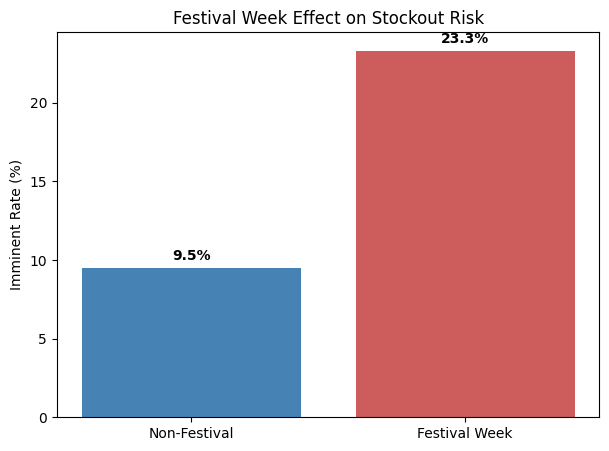

In [ ]:
imminent_rates = (
    data.groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Non-Festival", "Festival Week"],
    [imminent_rates["N"], imminent_rates["Y"]],
    color=["steelblue", "indianred"]
)

plt.ylabel("Imminent Rate (%)")
plt.title("Festival Week Effect on Stockout Risk")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

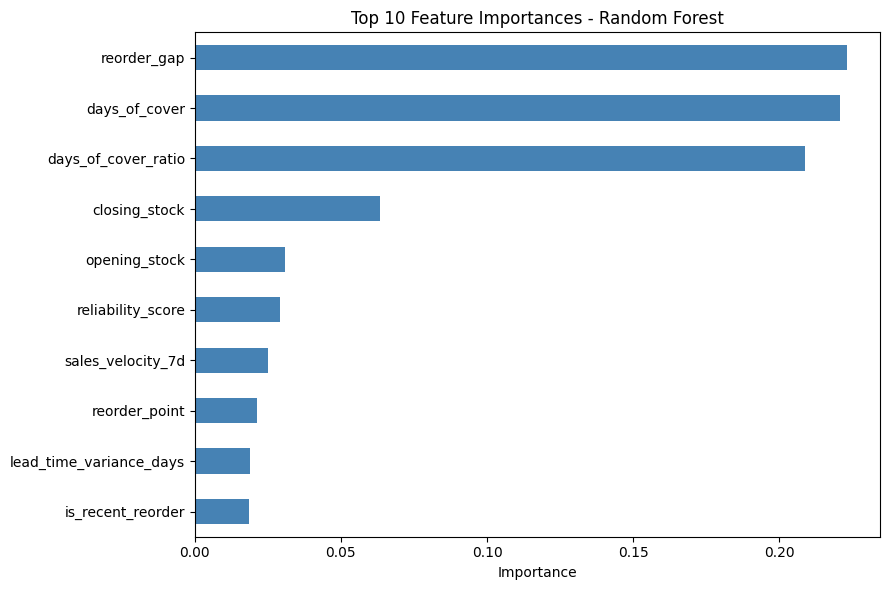

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importance.head(10)

plt.figure(figsize=(9, 6))

top_features.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, recall_score

print("=== RANDOM FOREST FINAL RESULTS ===")

print("Accuracy:")
print(round(accuracy_score(y_test, rf_pred), 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

=== RANDOM FOREST FINAL RESULTS ===
Accuracy:
0.943

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.84      0.92      0.88      1126
    Imminent       0.87      0.75      0.80       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.94      5040
   macro avg       0.90      0.89      0.89      5040
weighted avg       0.94      0.94      0.94      5040



In [ ]:
imminent_recall = recall_score(
    y_test,
    rf_pred,
    labels=["Imminent"],
    average="macro",
    zero_division=0
)

print("Imminent Recall:", round(imminent_recall, 3))

Imminent Recall: 0.751


In [ ]:
def reliability_group(x):
    if x < 0.75:
        return "Low"
    elif x < 0.85:
        return "Mid"
    else:
        return "High"

data["reliability_group"] = data["reliability_score"].apply(
    reliability_group
)

supplier_result = data.groupby(
    "reliability_group"
)["stockout_risk"].apply(
    lambda x: (x == "Imminent").mean() * 100
)

print("Imminent Rate by Supplier Reliability:")
print(supplier_result.round(2))

Imminent Rate by Supplier Reliability:
reliability_group
High     3.82
Low     13.07
Mid      3.26
Name: stockout_risk, dtype: float64


In [ ]:
perishable_result = data.groupby(
    "is_perishable"
)["stockout_risk"].apply(
    lambda x: (x == "Imminent").mean() * 100
)

print("Imminent Rate by Perishable Status:")
print(perishable_result.round(2))

Imminent Rate by Perishable Status:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64


In [ ]:
festival_result = data.groupby(
    "is_festival_week"
)["stockout_risk"].apply(
    lambda x: (x == "Imminent").mean() * 100
)

print("Imminent Rate by Festival Week:")
print(festival_result.round(2))

Imminent Rate by Festival Week:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64


In [ ]:
print("MODEL COMPARISON")
print(results_df)

MODEL COMPARISON
                 Model  Accuracy  Imminent Recall
0             Baseline     0.623            0.000
1  Logistic Regression     0.916            0.901
2        Random Forest     0.943            0.751


In [ ]:
print("TOP 10 FEATURES")
print(top_features)

TOP 10 FEATURES
reorder_gap                0.223331
days_of_cover              0.220678
days_of_cover_ratio        0.208856
closing_stock              0.063509
opening_stock              0.031014
reliability_score          0.029174
sales_velocity_7d          0.024953
reorder_point              0.021190
lead_time_variance_days    0.018776
is_recent_reorder          0.018402
dtype: float64


In [ ]:
print("FINAL PROJECT SUMMARY")
print("---------------------")

print("Dataset size:", len(data))

print("\nTarget distribution:")
print(data["stockout_risk"].value_counts())

print("\nFestival Imminent rates:")
print(festival_result.round(2))

print("\nSupplier reliability Imminent rates:")
print(supplier_result.round(2))

print("\nPerishable Imminent rates:")
print(perishable_result.round(2))

print("\nModel comparison:")
print(results_df)

print("\nRandom Forest Imminent Recall:",
      round(imminent_recall, 3))

FINAL PROJECT SUMMARY
---------------------
Dataset size: 21600

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Festival Imminent rates:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64

Supplier reliability Imminent rates:
reliability_group
High     3.82
Low     13.07
Mid      3.26
Name: stockout_risk, dtype: float64

Perishable Imminent rates:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64

Model comparison:
                 Model  Accuracy  Imminent Recall
0             Baseline     0.623            0.000
1  Logistic Regression     0.916            0.901
2        Random Forest     0.943            0.751

Random Forest Imminent Recall: 0.751
